In [1]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("fridrichmrtn/e-commerce-churn-dataset-rees46")

print(os.listdir(path))

['rees46_customer_model.csv', 'rees46_data_dictionary.csv']


In [2]:
import pandas as pd

full_file_path = os.path.join(path, 'rees46_customer_model.csv')
df = pd.read_csv(full_file_path)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 112610 entries, 0 to 112609
Columns: 276 entries, row_id to target_actual_profit
dtypes: float64(219), int64(57)
memory usage: 237.1 MB


In [3]:
full_dict_path = os.path.join(path, 'rees46_data_dictionary.csv')
dict = pd.read_csv(full_dict_path, encoding='cp1251')
dict

,Set,Attribute,Description,Variable name
0,Dependent,churn event,No transaction in future period.,target_event
1,Dependent,retention campaign profit,Incremental profit in future period.,target_actual_profit
2,Recency,session recency,time duration from the last session [days],session_recency
3,Recency,purchase recency,time duration from the last transaction [days],purchase_recency
4,Recency,time to session,time between sessions [days],inter_session_time
5,Recency,time to purchase,time between purchases [days],inter_purchase_time
6,Frequency,session number,user-session number [n],session_number
7,Frequency,purchase number,user-purchase number [n],purchase_number
8,Frequency,session daily frequency *,session count per day,session_count_ratio
9,Frequency,interaction daily frequency *,interaction count per day,click_count_ratio


## Предобработка данных

In [4]:
df['length_max'].describe()

count    112610.000000
mean      15210.105896
std       40388.028499
min           0.000000
25%          12.300000
50%          28.916667
75%          92.966667
max      243703.033333
Name: length_max, dtype: float64

Список временных шагов

In [5]:
time_steps = sorted(list(df.time_step.drop_duplicates()), reverse=True)
df['time_step'].value_counts()

time_step
0    21605
1    21030
2    19690
3    17821
4    14975
5    11233
6     6256
Name: count, dtype: int64

In [6]:
df['user_id'].nunique()

21605

Удаляем служебный столбец

In [7]:
df = df.drop('row_id', axis=1)

Список "неприкасаемых" колонок (таргеты, идентификаторы, служебные)

In [8]:
untouchable_cols = [
    'user_id', 'target_event', 'target_revenue',
    'target_customer_value', 'time_step',
    'target_customer_value_lag1', 'target_actual_profit'
]
untouchable_cols = [c for c in untouchable_cols if c in df.columns]
untouchable_cols

['user_id',
 'target_event',
 'target_revenue',
 'target_customer_value',
 'time_step',
 'target_customer_value_lag1',
 'target_actual_profit']

Исправление целевой переменной target_event

Отток должен быть окончательным: если пользователь «ушёл» на шаге 3, но потом внезапно появился на шаге 2 или 1 с target_event=0, значит первоначальная метка оттока была ошибочной (пользователь на самом деле не ушёл).

In [9]:
def right_target(row):
    """Исправляет метку оттока: если пользователь позже появляется с target_event=0,
       текущая метка 1 считается ошибочной и заменяется на 0."""
    uid = row['user_id']
    ts = row['time_step']
    churn = row['target_event']
    if churn == 1:
        # Проверяем, есть ли более поздние шаги с target_event == 0
        later_retention = ((df.user_id == uid) & (df.time_step < ts) & (df.target_event == 0)).any()
        if later_retention:
            return 0
    return churn

print("Исправление target_event...")
before = df['target_event'].value_counts().to_dict()
df['target_event'] = df.apply(right_target, axis=1)
after = df['target_event'].value_counts().to_dict()
print(f"Распределение ДО исправления: {before}")
print(f"Распределение ПОСЛЕ исправления: {after}")

Исправление target_event...
Распределение ДО исправления: {0: 76480, 1: 36130}
Распределение ПОСЛЕ исправления: {0.0: 83232, 1.0: 29378}


Фильтрация по длине сессии (length_max)

In [10]:
if 'length_max' in df.columns:
    # Порог в минутах: 4 недели
    q = 60 * 24 * 7 * 4
    outlier_count = (df['length_max'] > q).sum()
    print(f"Строк с length_max > {q} мин: {outlier_count}")
    if outlier_count > 0:
        df = df[df['length_max'] <= q]
        print(f"После фильтрации осталось строк: {len(df)}")
    else:
        print("Все значения в пределах порога, фильтрация не требуется")
else:
    print("Колонка 'length_max' не найдена")

Строк с length_max > 40320 мин: 14429
После фильтрации осталось строк: 98181


Удаление записей с невозможной конверсией

In [11]:
cond = False
if 'purchase_count_sum' in df.columns and 'view_count_sum' in df.columns:
    # Находим строки, где конверсия > 1 (покупок больше, чем просмотров)
    impossible = df['purchase_count_sum'] > df['view_count_sum']
    cnt = impossible.sum()
    print(f"Строк с невозможной конверсией: {cnt}")
    if cnt > 0:
        df = df[~impossible]
        print(f"После удаления осталось строк: {len(df)}")
    else:
        print("Некорректных строк не найдено")
else:
    print("Необходимые колонки отсутствуют")

Строк с невозможной конверсией: 59
После удаления осталось строк: 98122


Логарифмирование сильно смещённых признаков

In [12]:
import numpy as np

c = 0
log_cols = []

for col in df.columns:
    if col in untouchable_cols:
        continue
    q2 = df[col].quantile(0.5)
    if q2 == 0:
        continue
    m = df[col].mean()
    if (m > q2 * 4) or (q2 > m * 4):
        c += 1
        log_cols.append(col)

        min_val = df[col].min()
        # Подбираем сдвиг, чтобы гарантировать x + shift > 0 для всех x
        if min_val <= -1:
            shift = abs(min_val) + 1.1
        else:
            shift = 1.0
        df[col] = np.log10(df[col] + shift)
        # Выводим информацию, если сдвиг отличается от 1
        if shift != 1.0:
            print(f"Логарифмирование колонки '{col}': min={min_val:.2f}, сдвиг={shift:.2f}")

print(f"Всего преобразовано колонок: {c}")

Логарифмирование колонки 'customer_value_month_lag2': min=-66.33, сдвиг=67.43
Логарифмирование колонки 'customer_value_month_lag3': min=-62.18, сдвиг=63.28
Всего преобразовано колонок: 46


Винзоризация (ограничение выбросов по IQR)

In [13]:
def level_feeding(value):
    if value > upper_outlier_threshold:
        return upper_outlier_threshold
    if value < lower_outlier_threshold:
        return lower_outlier_threshold
    return value
volatile_cols = []
for col in df.columns:
    if col in untouchable_cols:
        continue
    q3 = df[col].quantile(0.75)
    q2 = df[col].quantile(0.5)
    q1 = df[col].quantile(0.25)
    iqr = q3 - q1
    upper_outlier_threshold = q3 + 3 * iqr
    lower_outlier_threshold = q1 - 3 * iqr
    print(col, len(df[(df[col] < lower_outlier_threshold) | (df[col] > upper_outlier_threshold)]))
    df[col] = df[col].apply(level_feeding)

length_mean 3167
start_year_mean 0
start_yearday_mean 0
start_month_mean 0
start_monthday_mean 0
start_week_mean 0
start_weekday_mean 914
start_isweekend_mean 884
start_hour_mean 476
haspurchase_mean 0
click_count_mean 1166
view_count_mean 1380
cart_count_mean 627
purchase_count_mean 531
time_to_click_mean 4369
time_to_view_mean 4386
time_to_cart_mean 6852
time_to_purchase_mean 2695
view_revenue_mean 1220
cart_revenue_mean 2076
purchase_revenue_mean 2197
time_to_click_revenue_mean 5837
time_to_view_revenue_mean 5785
time_to_cart_revenue_mean 10470
time_to_purchase_revenue_mean 7357
session_number_mean 1681
inter_session_time_mean 3619
session_recency_mean 0
purchase_number_mean 1198
inter_purchase_time_mean 5681
purchase_recency_mean 0
length_sum 789
start_year_sum 1681
start_yearday_sum 1315
start_month_sum 1346
start_monthday_sum 1534
start_week_sum 1319
start_weekday_sum 1611
start_isweekend_sum 1357
start_hour_sum 1642
haspurchase_sum 1198
click_count_sum 2413
view_count_sum 3153
c

Отбор признаков через карреляционный анализ

In [14]:
correlate_cols = []
c = 0
for col in df.columns:
    if col in untouchable_cols:
        continue
    if ('start_' in col) or ('target' in col) or ('cv' in col) or ('max' in col) or ('min' in col) or ('stddev' in col) :
        continue
    correlate_cols.append(col)
    c += 1
c

128

In [15]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

# Загрузка матрицы корреляций
corr_matrix = df[correlate_cols].corr().dropna(how='all').dropna(axis=1, how='all')
corr_df = corr_matrix

# Преобразование корреляционной матрицы в расстояние
dist_matrix = 1 - np.abs(corr_df)
# Построение матрицы связей
linkage_matrix = linkage(squareform(dist_matrix), method='average')
# Кластеризация признаков с порогом 0.1
cluster_labels = fcluster(linkage_matrix, t=0.1, criterion='distance')

# Группировка признаков по кластерам
clustered_features = pd.DataFrame({'feature': corr_df.columns, 'cluster': cluster_labels})
grouped = clustered_features.groupby('cluster')['feature'].apply(list)

# Выбор лучшего признака в группе (по длине имени — как суррогат интерпретируемости)
def select_best_feature_by_name(group):
    group = sorted(group, key=len)
    local_corr_matrix = corr_matrix.loc[group, group]
    group_sum = local_corr_matrix.sum()
    return group_sum[np.abs(group_sum) == np.abs(group_sum).max()].index[0]

# Получение лучших признаков
best_features = [select_best_feature_by_name(group) for group in grouped]
grouped_df = pd.DataFrame({'cluster_id': grouped.index, 'features': grouped.values, 'selected_feature': best_features})

grouped_df

,cluster_id,features,selected_feature
0,1,[view_latent_factor4],view_latent_factor4
1,2,[purchase_latent_factor1],purchase_latent_factor1
2,3,[view_latent_factor16],view_latent_factor16
3,4,[purchase_latent_factor4],purchase_latent_factor4
4,5,[view_latent_factor30],view_latent_factor30
...,...,...,...
76,77,[purchase_revenue_month_lag1],purchase_revenue_month_lag1
77,78,[session_count_month_lag1],session_count_month_lag1
78,79,[view_latent_factor6],view_latent_factor6
79,80,[purchase_latent_factor3],purchase_latent_factor3


In [16]:
df = df[best_features + ['time_step', 'target_event']]
df.info()

<class 'pandas.DataFrame'>
Index: 98122 entries, 1 to 112609
Data columns (total 83 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   view_latent_factor4            98122 non-null  float64
 1   purchase_latent_factor1        98122 non-null  float64
 2   view_latent_factor16           98122 non-null  float64
 3   purchase_latent_factor4        98122 non-null  float64
 4   view_latent_factor30           98122 non-null  float64
 5   purchase_latent_factor12       98122 non-null  float64
 6   view_latent_factor17           98122 non-null  float64
 7   view_latent_factor1            98122 non-null  float64
 8   purchase_latent_factor2        98122 non-null  float64
 9   purchase_latent_factor14       98122 non-null  float64
 10  view_latent_factor23           98122 non-null  float64
 11  purchase_latent_factor9        98122 non-null  float64
 12  view_latent_factor35           98122 non-null  float64
 13  p

In [17]:
def get_train_test_split(data, features=None, target='target_event', split_step=1):
    """
    Разделяет данные на обучающую и тестовую выборки по временному срезу.
    Тест: все записи с time_step == split_step
    Обучающая: time_step > split_step (более ранние периоды)
    Возвращаемые выборки сортируются по убыванию time_step,
    что даёт хронологический порядок (от прошлого к настоящему).
    """
    if features is None:
        features = [c for c in data.columns
                    if c not in untouchable_cols
                    and not c.startswith('start_')]
    
    # Проверка наличия колонок
    missing = [c for c in features + [target, 'time_step'] if c not in data.columns]
    if missing:
        raise KeyError(f"Отсутствуют колонки: {missing}")
    
    test = data[data['time_step'] == split_step]
    train = data[data['time_step'] > split_step]
    
    # Сортировка по убыванию time_step для обеспечения хронологии
    # (time_step больше → более ранний период; убывание даёт порядок от прошлого к настоящему)
    train = train.sort_values('time_step', ascending=False)
    test = test.sort_values('time_step', ascending=False)
    
    print(f"Train size: {train.shape}, Test size: {test.shape}")
    return train[features], train[target], test[features], test[target]

X_train, y_train, X_test, y_test = get_train_test_split(df)

Train size: (66693, 83), Test size: (15458, 83)


In [18]:
y_train.value_counts(normalize=True)

target_event
0.0    0.876899
1.0    0.123101
Name: proportion, dtype: float64

In [19]:
y_test.value_counts()

target_event
0.0    9287
1.0    6171
Name: count, dtype: int64

Стандартизация

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## Построение и обучение моделей

### Логистическая регрессия

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

param_grid = [
    {'C': np.logspace(-4, 4, 9), 'l1_ratio': [0]},              # Чистый L2
    {'C': np.logspace(-4, 4, 9), 'l1_ratio': [1]},              # Чистый L1
    {'C': np.logspace(-4, 4, 9), 'l1_ratio': [0.2, 0.5, 0.8]},  # ElasticNet
    {'C': [1e6, 1e7, 1e8], 'l1_ratio': [0]}                     # Практически без регуляризации
]

tscv = TimeSeriesSplit(n_splits=5)
lr_gs = GridSearchCV(
    LogisticRegression(class_weight='balanced', solver='saga'),
    param_grid,
    cv=tscv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

lr_gs.fit(X_train_scaled, y_train)
print(f"Best: {lr_gs.best_params_} | Score: {lr_gs.best_score_:.4f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best: {'C': np.float64(10000.0), 'l1_ratio': 0} | Score: 0.5485


In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score
from sklearn.metrics import roc_curve, precision_recall_curve, auc, RocCurveDisplay, PrecisionRecallDisplay

best_lr = lr_gs.best_estimator_
y_pred = best_lr.predict(X_test_scaled)

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy:  0.7938
Precision: 0.6842
Recall:    0.8976
F1-score:  0.7765

Classification Report:
               precision    recall  f1-score   support

         0.0       0.91      0.72      0.81      9287
         1.0       0.68      0.90      0.78      6171

    accuracy                           0.79     15458
   macro avg       0.80      0.81      0.79     15458
weighted avg       0.82      0.79      0.80     15458



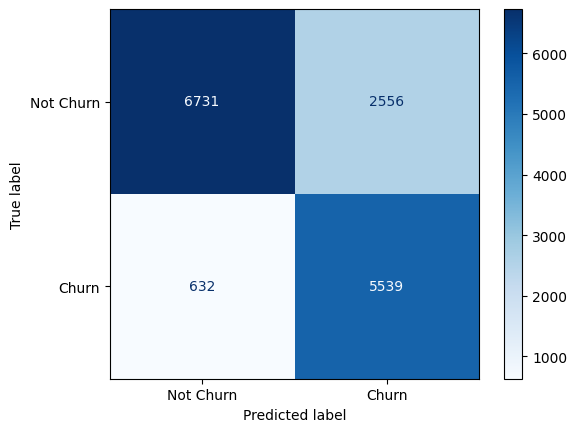

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    best_lr, X_test_scaled, y_test,
    display_labels=['Not Churn', 'Churn'],
    cmap='Blues',
    values_format='d'
)

### Дерево решений

In [24]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# Сетка параметров
param_grid_coarse = {
    'max_depth': [7, 10, 20, None],
    'min_samples_leaf': [5, 20, 50],
    'max_features': ['sqrt', 'log2', 0.5],
    'min_samples_split': [30, 50, 100],
    'max_leaf_nodes': [100, 500]
}

grid_search = GridSearchCV(dt, param_grid_coarse, cv=tscv, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [7, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'max_leaf_nodes': [100, 500], 'min_samples_leaf': [5, 20, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the com

In [25]:
best_model_dt = grid_search.best_estimator_
y_pred = best_model_dt.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred)
prec_dt = precision_score(y_test, y_pred)
rec_dt = recall_score(y_test, y_pred)
f1_dt = f1_score(y_test, y_pred)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучший score на валидации: {grid_search.best_score_}\n")
print(f"Accuracy: {acc_dt:.4f}")
print(f"Precision: {prec_dt:.4f}")
print(f"Recall: {rec_dt:.4f}")
print(f"F1-score: {f1_dt:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Лучшие параметры: {'max_depth': None, 'max_features': 0.5, 'max_leaf_nodes': 500, 'min_samples_leaf': 5, 'min_samples_split': 30}
Лучший score на валидации: 0.6467208793320796

Accuracy: 0.8235
Precision: 0.7257
Recall: 0.8966
F1-score: 0.8022

Classification Report:
               precision    recall  f1-score   support

         0.0       0.92      0.77      0.84      9287
         1.0       0.73      0.90      0.80      6171

    accuracy                           0.82     15458
   macro avg       0.82      0.84      0.82     15458
weighted avg       0.84      0.82      0.83     15458



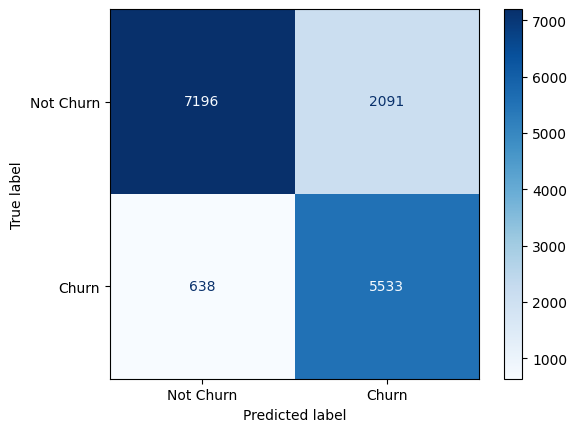

In [26]:
ConfusionMatrixDisplay.from_estimator(
    best_model_dt, X_test, y_test,
    display_labels=['Not Churn', 'Churn'],
    cmap='Blues',
    values_format='d'
)

### Случайный лес

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight='balanced', random_state=42)

param_grid = {
    'n_estimators': [150, 200, 300, 500],
    'min_samples_leaf': [5, 10, 15],
    'max_depth': [10, 20, 30, 50, None]
}

grid_search1 = GridSearchCV(rf, param_grid, cv=tscv, scoring='f1', n_jobs=-1)
grid_search1.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [5, 10, ...], 'n_estimators': [150, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and paramete

In [28]:
best_model_rf = grid_search1.best_estimator_
y_pred = best_model_rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred)
prec_rf = precision_score(y_test, y_pred)
rec_rf = recall_score(y_test, y_pred)
f1_rf = f1_score(y_test, y_pred)

print(f"Лучшие параметры: {grid_search1.best_params_}")
print(f"Лучший score на валидации: {grid_search1.best_score_}\n")
print(f"Accuracy: {acc_rf:.4f}")
print(f"Precision: {prec_rf:.4f}")
print(f"Recall: {rec_rf:.4f}")
print(f"F1-score: {f1_rf:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Лучшие параметры: {'max_depth': 30, 'min_samples_leaf': 10, 'n_estimators': 500}
Лучший score на валидации: 0.7356934887623894

Accuracy: 0.8771
Precision: 0.8373
Recall: 0.8590
F1-score: 0.8480

Classification Report:
               precision    recall  f1-score   support

         0.0       0.90      0.89      0.90      9287
         1.0       0.84      0.86      0.85      6171

    accuracy                           0.88     15458
   macro avg       0.87      0.87      0.87     15458
weighted avg       0.88      0.88      0.88     15458



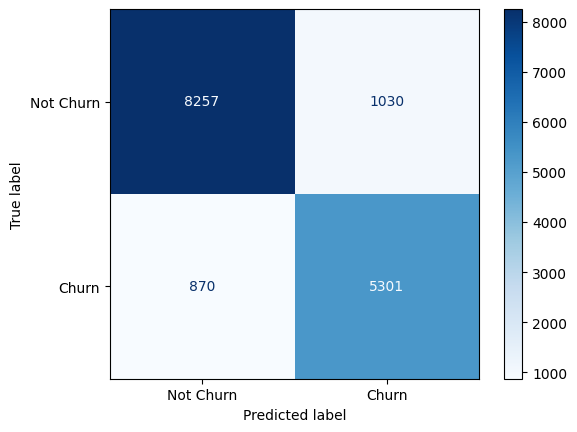

In [29]:
ConfusionMatrixDisplay.from_estimator(
    best_model_rf, X_test, y_test,
    display_labels=['Not Churn', 'Churn'],
    cmap='Blues',
    values_format='d'
)

### Бустинг

Вычисление соотношения классов для scale_pos_weight

In [30]:
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos
print(f"Соотношение классов: {scale_pos_weight:.2f}")

Соотношение классов: 7.12


XGBoost

In [31]:
from xgboost import XGBClassifier

xgb_params = {
    'n_estimators': [150, 200, 250],
    'learning_rate': [0.05, 0.07, 0.1],
    'max_depth': [5, 7, 9],
    'reg_alpha': [0.1, 0.5, 0.7],
    'reg_lambda': [5, 8, 10]
}
xgb_clf = XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=scale_pos_weight)
xgb_grid = GridSearchCV(xgb_clf, xgb_params, cv=tscv, scoring='f1', n_jobs=-1)
xgb_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.07, ...], 'max_depth': [5, 7, ...], 'n_estimators': [150, 200, ...], 'reg_alpha': [0.1, 0.5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the comput

In [32]:
xgb_best = xgb_grid.best_estimator_
y_pred = xgb_best.predict(X_test)

print("XGBoost best params:", xgb_grid.best_params_)
print("XGBoost best score:", xgb_grid.best_score_)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

XGBoost best params: {'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 200, 'reg_alpha': 0.5, 'reg_lambda': 5}
XGBoost best score: 0.7481793743893823
Accuracy: 0.8807
Precision: 0.8859
Recall: 0.8049
F1-score: 0.8434

Classification Report:
               precision    recall  f1-score   support

         0.0       0.88      0.93      0.90      9287
         1.0       0.89      0.80      0.84      6171

    accuracy                           0.88     15458
   macro avg       0.88      0.87      0.87     15458
weighted avg       0.88      0.88      0.88     15458



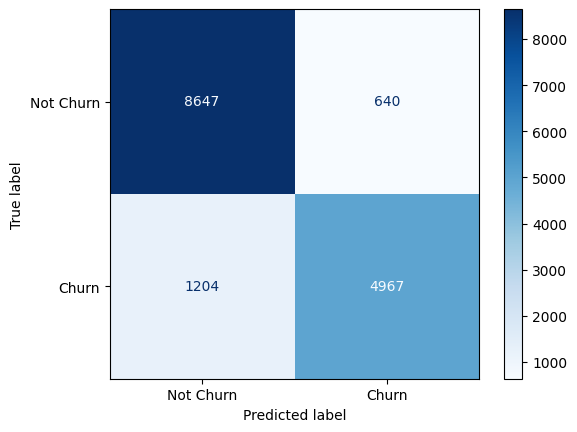

In [33]:
ConfusionMatrixDisplay.from_estimator(
    xgb_best, X_test, y_test,
    display_labels=['Not Churn', 'Churn'],
    cmap='Blues',
    values_format='d'
)

### Leaf Model

In [34]:
from scripts.leaf_model import LeafModel
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

base_selector = SelectKBest(score_func=f_classif)
base_tree = DecisionTreeClassifier(max_leaf_nodes=3, random_state=42)
odel_lr = LeafModel(
    tree=base_tree, 
    leaf_model=LogisticRegression(max_iter=1000, random_state=42),
    feature_selector=base_selector
)

param_grid = {
    'feature_selector__k': [5, 7, 10, 15, 20],
    'leaf_model__C': [0.01, 0.05, 0.1, 1.0, 10.0]
}

grid = GridSearchCV(odel_lr, param_grid=param_grid, cv=tscv, scoring='f1', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

llm_best = grid.best_estimator_
y_pred = llm_best.predict(X_test_scaled)
y_prob = llm_best.predict_proba(X_test_scaled)[:, 1]

print(f"✅ Best Params: {grid.best_params_}")
print(f"Acc: {accuracy_score(y_test, y_pred):.4f} | Prec: {precision_score(y_test, y_pred):.4f} | Rec: {recall_score(y_test, y_pred):.4f} | F1: {f1_score(y_test, y_pred):.4f} | ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(classification_report(y_test, y_pred, zero_division=0))

✅ Best Params: {'feature_selector__k': 5, 'leaf_model__C': 0.01}
Acc: 0.8673 | Prec: 0.9073 | Rec: 0.7436 | F1: 0.8173 | ROC-AUC: 0.9426
              precision    recall  f1-score   support

         0.0       0.85      0.95      0.90      9287
         1.0       0.91      0.74      0.82      6171

    accuracy                           0.87     15458
   macro avg       0.88      0.85      0.86     15458
weighted avg       0.87      0.87      0.86     15458



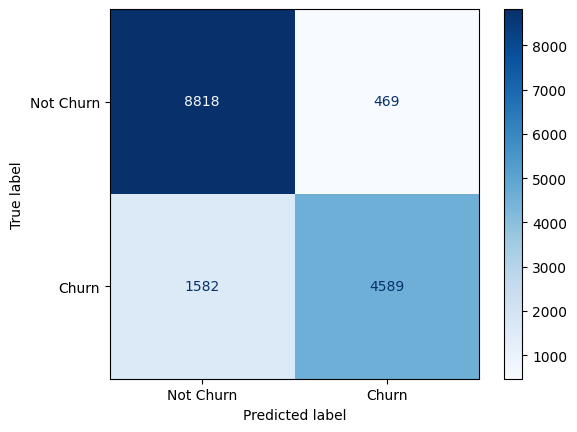

In [35]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Not Churn', 'Churn'],
    cmap='Blues',
    values_format='d'
)

In [36]:
from sklearn.ensemble import GradientBoostingClassifier

base_selector = SelectKBest(score_func=mutual_info_classif, k=5)
base_tree = DecisionTreeClassifier(max_leaf_nodes=3, random_state=42)
model_gb = LeafModel(tree=base_tree, 
                     leaf_model=GradientBoostingClassifier(random_state=42),
                     feature_selector=base_selector)

grid = GridSearchCV(model_gb, param_grid={
    'leaf_model__n_estimators': [50, 100, 150], 
    'leaf_model__max_depth': [3, 5, 7], 
    'leaf_model__learning_rate': [0.01, 0.1, 0.2]
}, cv=tscv, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

gb_lm_best = grid.best_estimator_
y_pred = gb_lm_best.predict(X_test)
y_prob = gb_lm_best.predict_proba(X_test)[:, 1]

print(f"✅ Best Params: {grid.best_params_}")
print(f"Acc: {accuracy_score(y_test, y_pred):.4f} | Prec: {precision_score(y_test, y_pred):.4f} | Rec: {recall_score(y_test, y_pred):.4f} | F1: {f1_score(y_test, y_pred):.4f} | ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(classification_report(y_test, y_pred, zero_division=0))

✅ Best Params: {'leaf_model__learning_rate': 0.01, 'leaf_model__max_depth': 3, 'leaf_model__n_estimators': 50}
Acc: 0.8723 | Prec: 0.8202 | Rec: 0.8710 | F1: 0.8449 | ROC-AUC: 0.9431
              precision    recall  f1-score   support

         0.0       0.91      0.87      0.89      9287
         1.0       0.82      0.87      0.84      6171

    accuracy                           0.87     15458
   macro avg       0.87      0.87      0.87     15458
weighted avg       0.87      0.87      0.87     15458



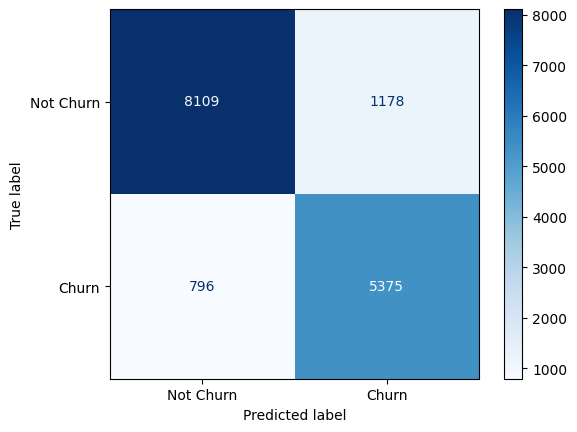

In [37]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Not Churn', 'Churn'],
    cmap='Blues',
    values_format='d'
)

### Нейронная сеть

In [38]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.utils.class_weight import compute_class_weight

# Создаем тензоры PyTorch
X_train_tensor = torch.FloatTensor(X_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_train_tensor = torch.LongTensor(y_train.values.astype(np.int64))
y_test_tensor = torch.LongTensor(y_test.values.astype(np.int64))

# Создаем DataLoader
batch_size = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Нейронная сеть
class SimpleNN(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim):
        super(SimpleNN, self).__init__()
        layers = []
        prev_dim = input_dim
        
        for i, hidden_dim in enumerate(hidden_dims):
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.2))
            prev_dim = hidden_dim
        
        layers.append(nn.Linear(prev_dim, output_dim))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)
    
    def predict_proba(self, X):
        self.eval()
        with torch.no_grad():
            X_tensor = torch.FloatTensor(X)
            outputs = self.forward(X_tensor)
            probs = F.softmax(outputs, dim=1)
            return probs.numpy()
    
    def predict(self, X):
        probs = self.predict_proba(X)
        return np.argmax(probs, axis=1)

print("=" * 60)
print("NEURAL NETWORK TRAINING")
print("=" * 60)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Инициализация модели
input_dim = X_train_tensor.shape[1]
model = SimpleNN(
    input_dim=input_dim,
    hidden_dims=[128, 64, 32],
    output_dim=2
).to(device)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Обучение
n_epochs = 50
for epoch in range(n_epochs):
    model.train()
    total_loss = 0
    batch_count = 0
    
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        batch_count += 1
    
    if (epoch + 1) % 10 == 0:
        avg_loss = total_loss / batch_count if batch_count > 0 else 0
        print(f"Epoch [{epoch+1}/{n_epochs}], Loss: {avg_loss:.4f}")


print("\nMaking predictions...")

# Собираем предсказания
model.eval()
all_predictions = []
all_probs = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        outputs = model(batch_X)
        probs = F.softmax(outputs, dim=1)
        predictions = torch.argmax(outputs, dim=1)
        
        all_predictions.extend(predictions.cpu().tolist())
        all_probs.extend(probs[:, 1].cpu().tolist())
        all_labels.extend(batch_y.cpu().tolist())

# Преобразуем в numpy массивы
all_predictions_np = np.array(all_predictions)
all_probs_np = np.array(all_probs)
all_labels_np = np.array(all_labels)

print("\nCalculating metrics...")

accuracy_nn = accuracy_score(all_labels_np, all_predictions_np)
precision_nn = precision_score(all_labels_np, all_predictions_np)
recall_nn = recall_score(all_labels_np, all_predictions_np)
f1_nn = f1_score(all_labels_np, all_predictions_np)

print("\n" + "=" * 60)
print("NEURAL NETWORK RESULTS")
print("=" * 60)
print(f"Accuracy:  {accuracy_nn:.4f}")
print(f"Precision: {precision_nn:.4f}")
print(f"Recall:    {recall_nn:.4f}")
print(f"F1-Score:  {f1_nn:.4f}")

NEURAL NETWORK TRAINING
Epoch [10/50], Loss: 0.2306
Epoch [20/50], Loss: 0.2177
Epoch [30/50], Loss: 0.2108
Epoch [40/50], Loss: 0.2022
Epoch [50/50], Loss: 0.1963

Making predictions...

Calculating metrics...

NEURAL NETWORK RESULTS
Accuracy:  0.8152
Precision: 0.7100
Recall:    0.9080
F1-Score:  0.7968


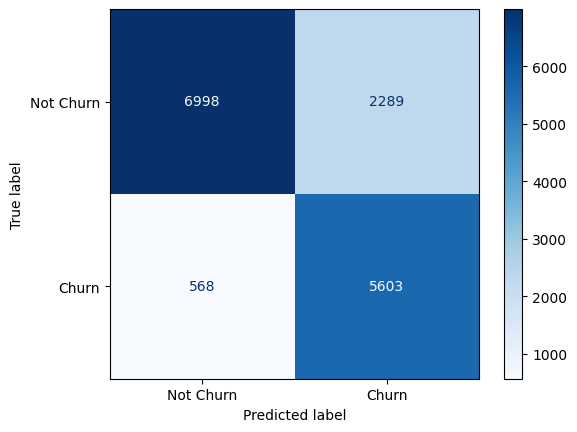

In [39]:
ConfusionMatrixDisplay.from_predictions(
    all_labels_np, all_predictions_np,
    display_labels=['Not Churn', 'Churn'],
    cmap='Blues',
    values_format='d'
)

In [40]:
import builtins
dict = builtins.dict

In [41]:
from pytorch_tabnet.tab_model import TabNetClassifier

# Разделение на train/val
val_size = int(len(X_train_scaled) * 0.1)

X_train_tb = X_train_scaled[:-val_size]
y_train_tb = y_train[:-val_size]

X_val_tb = X_train_scaled[-val_size:]
y_val_tb = y_train[-val_size:]

# Веса классов — считаем на y_train_tb
y_train_np = np.asarray(y_train_tb).ravel()
y_train_np = y_train_np.astype(int)
class_counts = np.bincount(y_train_np)
sample_weights = np.where(
    y_train_np == 1,
    len(y_train_np) / (2 * class_counts[1]),
    len(y_train_np) / (2 * class_counts[0])
)

best_params = {
    'n_d': 64,
    'n_a': 32,
    'n_steps': 3,
    'gamma': 1.5,
    'mask_type': 'entmax',
    'lr': 0.01,
    'weight_decay': 1e-4,
    'batch_size': 512,
}

clf = TabNetClassifier(
    n_d=best_params['n_d'],
    n_a=best_params['n_a'],
    n_steps=best_params['n_steps'],
    gamma=best_params['gamma'],
    mask_type=best_params['mask_type'],
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=best_params['lr'], weight_decay=best_params['weight_decay']),
    verbose=1
)

clf.fit(
    X_train=X_train_tb, y_train=y_train_tb,
    eval_set=[(X_val_tb, y_val_tb)],
    eval_name=["val"],
    eval_metric=["auc"],
    max_epochs=100,
    patience=10,
    batch_size=best_params['batch_size'],
    virtual_batch_size=128,
    weights=sample_weights,
    drop_last=False
)

c:\Users\Nikita\AppData\Local\Programs\Python\Python314\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.38855 | val_auc: 0.92845 |  0:00:03s
epoch 1  | loss: 0.22934 | val_auc: 0.94017 |  0:00:07s
epoch 2  | loss: 0.21796 | val_auc: 0.94363 |  0:00:10s
epoch 3  | loss: 0.20537 | val_auc: 0.94722 |  0:00:13s
epoch 4  | loss: 0.20555 | val_auc: 0.94458 |  0:00:17s
epoch 5  | loss: 0.209   | val_auc: 0.94453 |  0:00:20s
epoch 6  | loss: 0.20036 | val_auc: 0.94358 |  0:00:24s
epoch 7  | loss: 0.19914 | val_auc: 0.94463 |  0:00:27s
epoch 8  | loss: 0.19772 | val_auc: 0.94507 |  0:00:31s
epoch 9  | loss: 0.19367 | val_auc: 0.93462 |  0:00:34s
epoch 10 | loss: 0.19676 | val_auc: 0.94588 |  0:00:38s
epoch 11 | loss: 0.19336 | val_auc: 0.94405 |  0:00:42s
epoch 12 | loss: 0.19352 | val_auc: 0.94545 |  0:00:45s
epoch 13 | loss: 0.19094 | val_auc: 0.93605 |  0:00:50s

Early stopping occurred at epoch 13 with best_epoch = 3 and best_val_auc = 0.94722


c:\Users\Nikita\AppData\Local\Programs\Python\Python314\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [42]:
y_val_proba = clf.predict_proba(X_val_tb)[:, 1]
best_thr, best_f1 = 0.5, 0
for thr in np.arange(0.1, 0.9, 0.02):
    f1_t = f1_score(y_val_tb, (y_val_proba > thr).astype(int), zero_division=0)
    if f1_t > best_f1:
        best_f1 = f1_t
        best_thr = thr

print(f"\nОптимальный порог: {best_thr:.2f} (val F1={best_f1:.4f})")

y_test_proba = clf.predict_proba(X_test_scaled)[:, 1]
y_test_pred = (y_test_proba > best_thr).astype(int)

print("\n" + "=" * 60)
print("ФИНАЛЬНЫЕ МЕТРИКИ НА ТЕСТЕ")
print("=" * 60)
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall: {recall_score(y_test,y_test_pred):.4f}")
print(f"F1-score: {f1_score(y_test, y_test_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))


Оптимальный порог: 0.76 (val F1=0.7918)

ФИНАЛЬНЫЕ МЕТРИКИ НА ТЕСТЕ
Accuracy: 0.8709
Precision: 0.8350
Recall: 0.8431
F1-score: 0.8391

Classification Report:
               precision    recall  f1-score   support

         0.0       0.90      0.89      0.89      9287
         1.0       0.84      0.84      0.84      6171

    accuracy                           0.87     15458
   macro avg       0.87      0.87      0.87     15458
weighted avg       0.87      0.87      0.87     15458



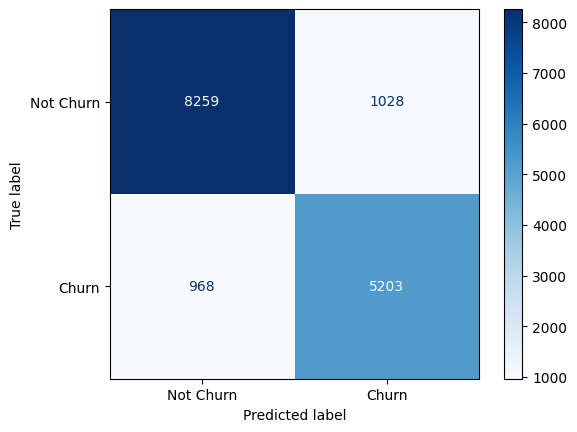

In [43]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred,
    display_labels=['Not Churn', 'Churn'],
    cmap='Blues',
    values_format='d'
)

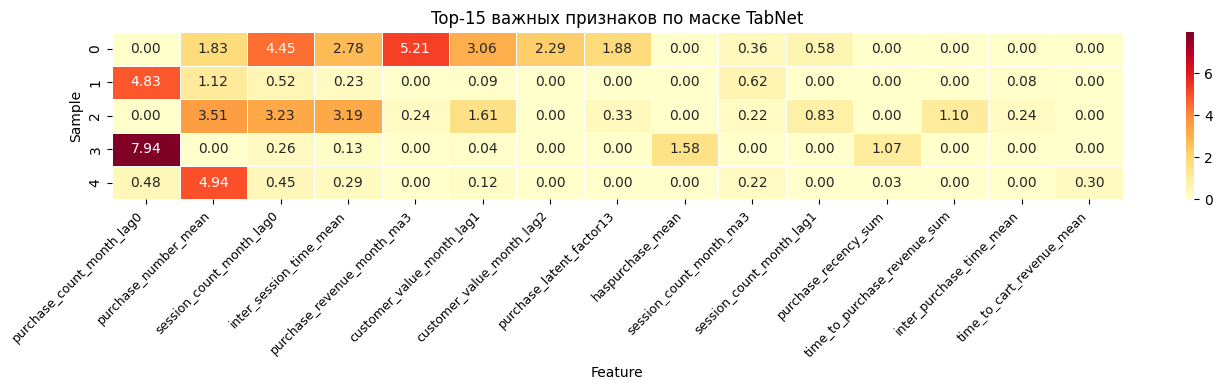

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

M_explain, _ = clf.explain(X_test_scaled[:5])

# Выбираем топ-K признаков по средней важности для этих 5 клиентов
K = 15
importance = M_explain.mean(axis=0)
top_indices = np.argsort(importance)[::-1][:K]

# Формируем сокращённую матрицу и подписи
M_top = M_explain[:, top_indices]
feature_names = X_train.columns[top_indices]

plt.figure(figsize=(14, 4))
sns.heatmap(
    M_top,
    xticklabels=feature_names,
    yticklabels=[f'{i}' for i in range(5)],
    cmap="YlOrRd",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)
plt.title(f"Top-{K} важных признаков по маске TabNet")
plt.xlabel("Feature")
plt.ylabel("Sample")
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

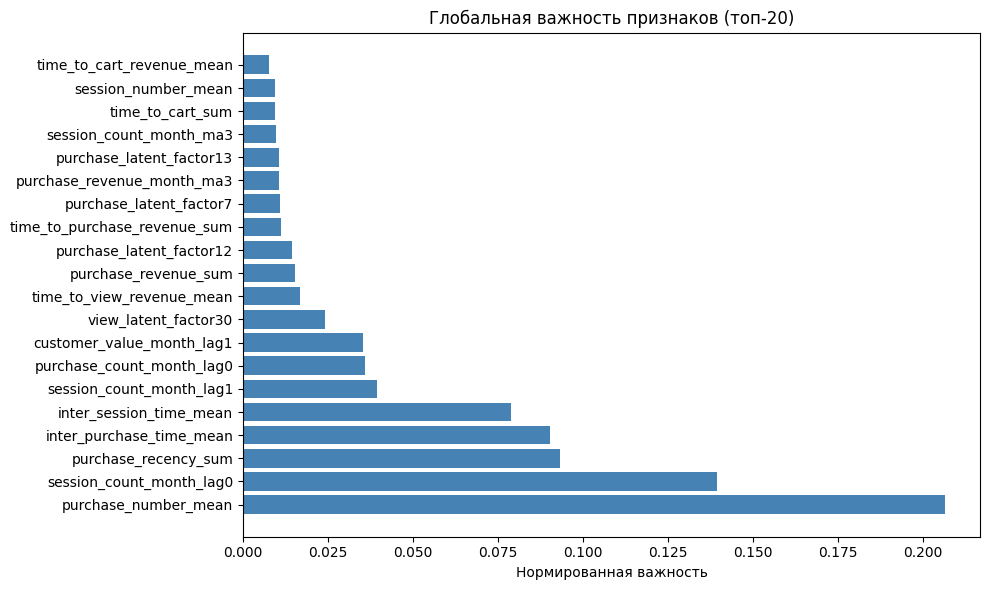

In [45]:
# Сбор масок и предсказаний
masks = []
for x in X_test_scaled:
    explanation = clf.explain(x.reshape(1, -1))
    masks.append(explanation[0])

masks = np.array(masks)
if masks.ndim == 3 and masks.shape[1] == 1:
    masks = masks.squeeze(1)

# Средняя маска по всем сэмплам (глобальная важность)
global_importance = np.mean(masks, axis=0)
feature_names = X_train.columns.tolist()

# Нормализуем для отображения в процентах
global_importance /= np.sum(global_importance)

# Выбираем топ-K признаков
K = 20
top_idx = np.argsort(global_importance)[::-1][:K]
top_imp = global_importance[top_idx]
top_names = np.array(feature_names)[top_idx]

# Горизонтальный bar plot
plt.figure(figsize=(10, 6))
bars = plt.barh(np.arange(K)[::-1], top_imp[::-1], color='steelblue')
plt.yticks(np.arange(K)[::-1], top_names[::-1])
plt.xlabel('Нормированная важность')
plt.title(f'Глобальная важность признаков (топ-{K})')
plt.tight_layout()
plt.show()

## Сравнение моделей

Модель                    |  ROC-AUC |   PR-AUC
---------------------------------------------
LogisticRegression        |   0.9175 |   0.8921
DecisionTree              |   0.8989 |   0.9034
RandomForest              |   0.9491 |   0.9305
XGBoost                   |   0.9481 |   0.9329
LogitLeafModel            |   0.9426 |   0.9152
GBLeafModel               |   0.9431 |   0.9249
MLP                       |   0.9325 |   0.9137
TabNet                    |   0.9404 |   0.9182


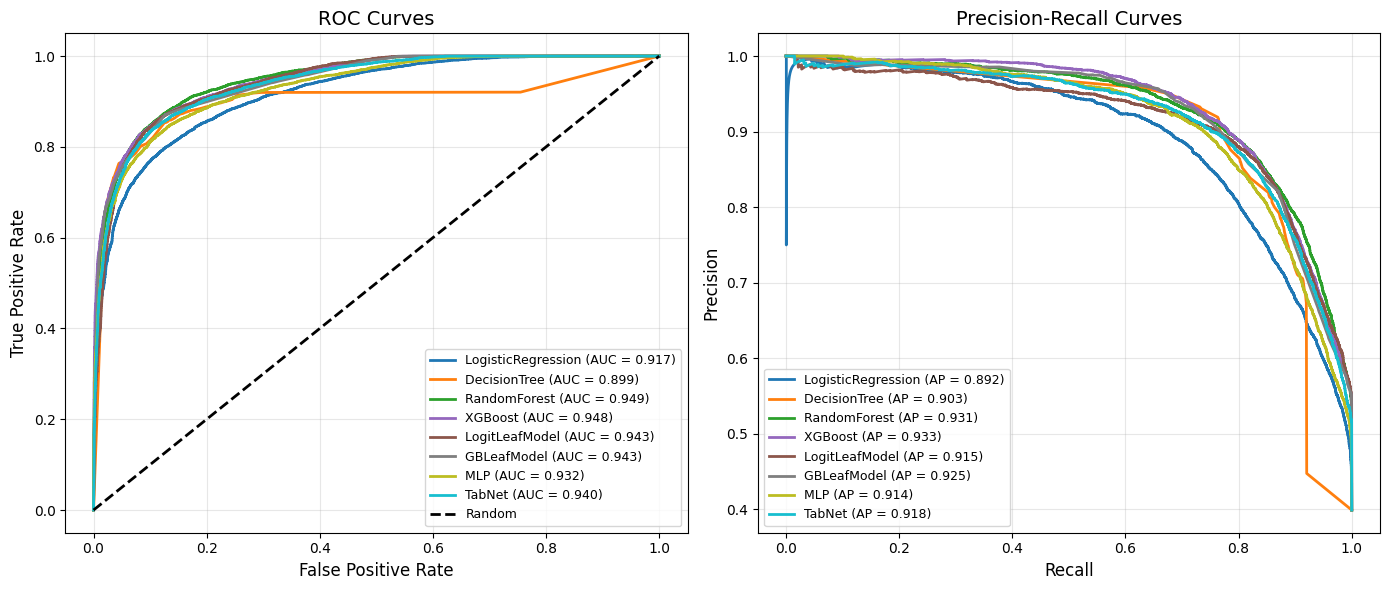

In [46]:
models = {
    'LogisticRegression': best_lr,
    'DecisionTree': best_model_dt,
    'RandomForest': best_model_rf,
    'XGBoost': xgb_best,
    'LogitLeafModel': llm_best,
    'GBLeafModel': gb_lm_best,
    'MLP': model,
    'TabNet': clf
}

# Тестовые данные для каждой модели
test_data = {
    'LogisticRegression': (X_test_scaled, y_test),
    'DecisionTree': (X_test, y_test),
    'RandomForest': (X_test, y_test),
    'XGBoost': (X_test, y_test),
    'LogitLeafModel': (X_test_scaled, y_test),
    'GBLeafModel': (X_test, y_test),
    'MLP': (X_test_scaled, y_test),
    'TabNet': (X_test_scaled, y_test)
}

roc_curves = {}
pr_curves = {}
auc_scores = {}
ap_scores = {}

for name, mdl in models.items():
    X_t, y_t = test_data[name]

    if hasattr(mdl, 'predict_proba'):
        y_score = mdl.predict_proba(X_t)[:, 1]
    else:
        y_score = mdl.predict(X_t)

    # ROC
    fpr, tpr, _ = roc_curve(y_t, y_score)
    roc_curves[name] = (fpr, tpr)
    auc_scores[name] = auc(fpr, tpr)

    # Precision-Recall
    precision, recall, _ = precision_recall_curve(y_t, y_score)
    pr_curves[name] = (precision, recall)
    ap_scores[name] = auc(recall, precision)

# Таблица метрик
print(f"{'Модель':<25} | {'ROC-AUC':>8} | {'PR-AUC':>8}")
print("-" * 45)
for name in models:
    print(f"{name:<25} | {auc_scores[name]:>8.4f} | {ap_scores[name]:>8.4f}")

# Графики
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(models)))

# ROC
for i, (name, (fpr, tpr)) in enumerate(roc_curves.items()):
    ax1.plot(fpr, tpr, color=colors[i], linewidth=2,
             label=f'{name} (AUC = {auc_scores[name]:.3f})')

ax1.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random')
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('ROC Curves', fontsize=14)
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(True, alpha=0.3)

# PR
for i, (name, (precision, recall)) in enumerate(pr_curves.items()):
    ax2.plot(recall, precision, color=colors[i], linewidth=2,
             label=f'{name} (AP = {ap_scores[name]:.3f})')

ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall Curves', fontsize=14)
ax2.legend(loc='lower left', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [47]:
import shap

# Явная группировка всех 81 признака
FEATURE_GROUPS = {
    'Preference': [
        'view_latent_factor4', 'purchase_latent_factor1', 'view_latent_factor16', 'purchase_latent_factor4',
        'view_latent_factor30', 'purchase_latent_factor12', 'view_latent_factor17', 'view_latent_factor1',
        'purchase_latent_factor2', 'purchase_latent_factor14', 'view_latent_factor23', 'purchase_latent_factor9',
        'view_latent_factor35', 'purchase_latent_factor7', 'purchase_latent_factor6', 'purchase_latent_factor13',
        'purchase_latent_factor0', 'view_latent_factor2', 'purchase_latent_factor10', 'view_latent_factor31',
        'view_latent_factor6', 'purchase_latent_factor3', 'purchase_latent_factor15'
    ],
    'Frequency': [
        'view_count_sum', 'session_number_mean', 'session_number_sum', 'purchase_number_mean', 'cart_count_sum',
        'view_count_mean', 'haspurchase_mean', 'purchase_count_mean', 'cart_count_mean', 'purchase_count_month_lag2',
        'session_count_month_lag2', 'purchase_count_month_lag3', 'session_count_month_lag3', 'purchase_count_month_lag0',
        'session_count_month_lag0', 'session_count_month_ma3', 'purchase_count_month_ma3', 'session_count_ratio',
        'click_count_ratio', 'transaction_count_ratio', 'purchase_count_month_lag1', 'session_count_month_lag1'
    ],
    'Monetary': [
        'view_revenue_sum', 'cart_revenue_sum', 'purchase_revenue_sum', 'purchase_revenue_month_lag2',
        'customer_value_month_lag2', 'purchase_revenue_month_lag3', 'customer_value_month_lag3',
        'purchase_revenue_month_lag0', 'customer_value_month_lag1', 'customer_value_month_ma3',
        'customer_value_month_lag0', 'purchase_revenue_month_ma3', 'purchase_revenue_month_lag1',
        'purchase_revenue_mean', 'view_revenue_mean', 'cart_revenue_mean'
    ],
    'Recency': [
        'inter_session_time_mean', 'inter_purchase_time_mean', 'inter_session_time_sum', 'inter_purchase_time_sum',
        'session_recency_mean', 'session_recency_sum', 'purchase_recency_sum'
    ],
    'Others': [
        'time_to_cart_revenue_mean', 'time_to_cart_revenue_sum', 'time_to_cart_mean', 'time_to_cart_sum',
        'time_to_view_revenue_mean', 'time_to_purchase_revenue_mean', 'time_to_click_sum', 'time_to_purchase_sum',
        'time_to_view_revenue_sum', 'time_to_purchase_revenue_sum', 'time_to_view_mean', 'length_mean',
        'time_to_purchase_mean'
    ]
}

# Инвертируем маппинг: {feature_name: group_name}
FEATURE_TO_GROUP = {feat: grp for grp, feats in FEATURE_GROUPS.items() for feat in feats}

# Проверка покрытия всех признаков из модели
model_features = set(xgb_best.feature_names_in_)
assert len(model_features) == 81, f"Ожидается 81 признак, в модели найдено {len(model_features)}"
missing = model_features - set(FEATURE_TO_GROUP.keys())
assert not missing, f"Не сгруппированы: {missing}"
extra = set(FEATURE_TO_GROUP.keys()) - model_features
assert not extra, f"В группировке есть лишние признаки: {extra}"


# Расчет важности XGBoost (встроенный gain/importance)
xgb_imp = pd.Series(xgb_best.feature_importances_, index=xgb_best.feature_names_in_)

# Расчет важности SHAP
explainer = shap.TreeExplainer(xgb_best)
shap_explanation = explainer(X_train)

# Глобальная важность SHAP = среднее абсолютное влияние по всем объектам
shap_imp = pd.Series(np.abs(shap_explanation.values).mean(axis=0), index=xgb_best.feature_names_in_)

# Сборка таблицы и агрегация по группам
df_feat = pd.DataFrame({
    'Feature': xgb_imp.index,
    'XGB_Importance': xgb_imp.values,
    'SHAP_Importance': shap_imp.values
})
df_feat['Group'] = df_feat['Feature'].map(FEATURE_TO_GROUP)

# Агрегация: сумма и среднее по группам
agg_result = df_feat.groupby('Group').agg(
    XGB_Sum=('XGB_Importance', 'sum'),
    XGB_Mean=('XGB_Importance', 'mean'),
    SHAP_Sum=('SHAP_Importance', 'sum'),
    SHAP_Mean=('SHAP_Importance', 'mean')
).round(4)

# Фиксируем порядок вывода как в запросе
desired_order = ['Preference', 'Frequency', 'Others', 'Monetary', 'Recency']
agg_result = agg_result.reindex(desired_order).fillna(0)

# Добавляем доли вклада (%) для наглядности
agg_result['XGB_Share_%'] = (agg_result['XGB_Sum'] / agg_result['XGB_Sum'].sum() * 100).round(2)
agg_result['SHAP_Share_%'] = (agg_result['SHAP_Sum'] / agg_result['SHAP_Sum'].sum() * 100).round(2)

# 5. Вывод результата
print("Агрегированная важность признаков по группам:")
print(agg_result.to_string(index=True))

Агрегированная важность признаков по группам:
            XGB_Sum  XGB_Mean  SHAP_Sum  SHAP_Mean  XGB_Share_%  SHAP_Share_%
Group                                                                        
Preference   0.0731    0.0032    0.7082     0.0308     7.310000      6.690000
Frequency    0.7952    0.0361    7.1528     0.3251    79.510002     67.559998
Others       0.0413    0.0032    0.7356     0.0566     4.130000      6.950000
Monetary     0.0655    0.0041    0.8403     0.0525     6.550000      7.940000
Recency      0.0250    0.0036    1.1512     0.1645     2.500000     10.870000
